# Baseline Model Runs: H-SAD Loss

This notebook contains the code used to train a Vision Transformer model using Hierarchical Semi-Supervised Anomaly Detection (H-SAD) loss. Key visualizations to analyze the model's outputs are also included.

**WARNING:** This function trains a model and saves its weights. However, these weights may not necessarily work as expected with `run_inference.py`. To avoid errors, only run `run_inference.py` with the model weights provided (`final_model.pth`) or those generated by the notebook `model_test_runs_finalized.ipynb`.

In [1]:
#Importing packages
import argparse
import os
from torch.utils.data import DataLoader
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import pandas as pd
from chromadb import PersistentClient as PersistentClient
from chromadb.errors import InternalError as CollectionError
import random
import numpy as np

#library functions
import src.dataloading as dataloading
import src.data_vis as data_vis
import src.model_functions as model_functions
import src.loss_functions as loss_functions
import src.models as models
from src.seeds import set_seed


KeyboardInterrupt: 

We set the seed for reproducibility, though results still vary slightly

In [ ]:
g = set_seed()

In [ ]:
labels_json = r"camera_data/coronado_hills_4pt.json"

device = 'cuda'

model_path = 'weights/'
model_name = "hsad_model.pth"

data = dataloading.get_data(labels_json, 'camera_data/images/', replace_images = False)

labeled_data = data[data['choice'] > -1]

full_train, _, _ = dataloading.get_train_val_test(data = data, output_csvs=False)

train, val, test = dataloading.get_train_val_test(data = labeled_data, output_csvs=True)

full_train_dataloader, _, _ = dataloading.get_train_val_test_dataloaders(full_train, val, test, generator = g)
train_dataloader, val_dataloader, test_dataloader = dataloading.get_train_val_test_dataloaders(train, val, test, generator = g)

100%|██████████| 7488/7488 [00:01<00:00, 6550.92it/s]


Instantiating the pre-trained model

In [ ]:
encoder = models.create_encoder()
encoder.to(device)
encoder.load_state_dict(torch.load('weights/model_weights_camera_10-27-25.pth', map_location=device, weights_only=True));

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Instantiating the training settings

In [ ]:
loss_func = loss_functions.HierarchicalSADLoss(model=encoder, train_data=train_dataloader, num_classes = 4, 
device = device, eta = 0.01, alpha = 10)
#loss_func = loss_functions.TripletMarginLoss(margin = 0.19)
optimizer = optim.Adam(encoder.parameters(), lr=1e-5, weight_decay=1e-6) 
num_epochs = 5

Training the model

In [ ]:
losses = model_functions.train_model(encoder, train_data=full_train_dataloader, 
                                    num_epochs=num_epochs, loss_func=loss_func, 
                                    optimizer=optimizer, name = model_name, path = 'weights/', device=device)

C:\Users\Aneesh\AppData\Local\Temp\ipykernel_30056\3764918031.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder.load_state_dict(torch.load(os.path.join(model_path,

Saving the embeddings generated by this model

In [ ]:
client = PersistentClient(path="embedding_data/") 

try:
    client.delete_collection(name="train_embeddings")
except Exception:
    pass

try:
    client.delete_collection(name="val_embeddings")
except Exception:
    pass


dataloading.save_full_embeddings(encoder, train_dataloader, 
                        "train_embeddings", persist_directory = "embedding_data/", 
                        device = device)


dataloading.save_full_embeddings(encoder, val_dataloader, 
                        "val_embeddings", persist_directory = "embedding_data/", 
                        device = device)
    
    
#Embeddings of training data, used to train the classification head
train_embeddings, train_labels, train_img_urls, train_a_ids = dataloading.load_full_embeddings(train, "train_embeddings", persist_directory = "embedding_data/")
train_embedding_dataloader = dataloading.embedding_to_dataloader(train_embeddings, train_labels, batch_size=32, generator = g)

#Embeddings of validation data, used to display results
val_embeddings, val_labels, _, _ = dataloading.load_full_embeddings(val, "val_embeddings", persist_directory = "embedding_data/")

Visualizing the first two principal axes of the embedding space

In [ ]:
reduced_embeddings, labels = model_functions.reduce_pca(train_embeddings, train_labels, dimensions=4)

Text(0.5, 1.0, 'First two axes of embedding space generated by H-SAD Loss Model')

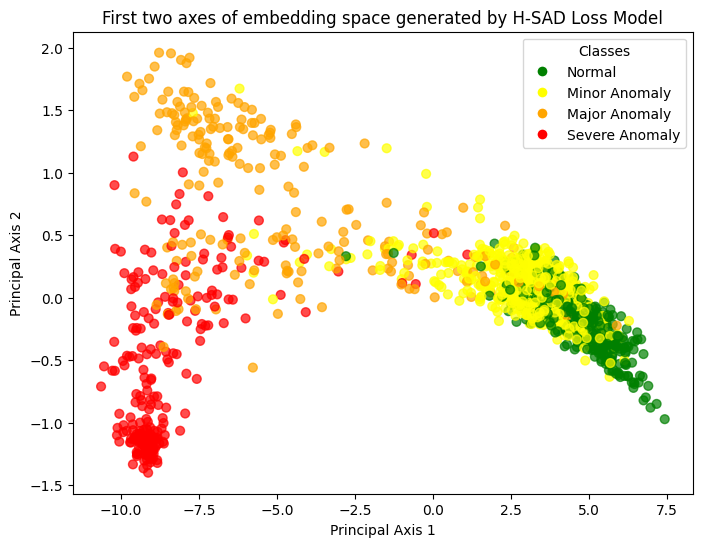

In [ ]:
colors = {0: "green", 1: "yellow", 2: "orange", 3: "red"}
names = {0: "Normal", 1: "Minor Anomaly", 2: "Major Anomaly", 3: "Severe Anomaly"}

fig, ax = plt.subplots(figsize=(8, 6))
ax = data_vis.plot_data(reduced_embeddings, labels, pcx = 1, pcy = 2, colors=colors, names = names, ax=ax)
ax.set_title("First two axes of embedding space generated by H-SAD Loss Model")

Training classification head

In [ ]:
losses = []

classification_head = models.ClassificationHead()
classification_head.to(device)

head_criterion = nn.CrossEntropyLoss()
head_optimizer = optim.Adam(classification_head.parameters(), lr=1e-3) # Optimize only the new head

losses = model_functions.train_classification_head(classification_head, train_embedding_dataloader, num_epochs=15, criterion=head_criterion, optimizer=head_optimizer, 
                           device=device, model_name=model_name, model_path = "weights/", save=True)

#Report training and validation accuracy
classification_head.eval()

Processing batches in epoch 14: 100%|██████████| 44/44 [00:03<00:00, 14.15it/s]


ClassificationHead(
  (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=4, bias=True)
  )
)

Testing classification head outputs

In [ ]:
train_embeddings_tensor = torch.Tensor(train_embeddings.to_numpy()).to(device)
val_embeddings_tensor = torch.Tensor(val_embeddings.to_numpy()).to(device)

train_labels_tensor = torch.Tensor(train_labels.to_numpy()).to(device)
val_labels_tensor = torch.Tensor(val_labels.to_numpy()).to(device)


train_outputs = classification_head(train_embeddings_tensor)
val_outputs = classification_head(val_embeddings_tensor)

print(f"Training accuracy: {(torch.argmax(train_outputs, dim = -1) == train_labels_tensor).float().mean().item()}")
print(f"Validation accuracy: {(torch.argmax(val_outputs, dim = -1) == val_labels_tensor).float().mean().item()}")

Training accuracy: 0.7716138362884521
Validation accuracy: 0.7775377631187439
